# Nova Scotia: Do Socioeconomic Conditions Shape Health — Even When Healthcare Is Free?
## Correlation Analysis — Extension of the NS Healthcare Access Project

**Date:** May 2026  
**Scope:** Province-level analysis linking income, education attainment, chronic disease prevalence, and life expectancy across Nova Scotia (2012–2022).

---

### The Central Question

Nova Scotia operates under Canada's universal, publicly funded healthcare system — every resident has access to physician services and hospital care **at no direct cost**. If healthcare access is "equal," should socioeconomic status still predict who gets sick?

This notebook investigates exactly that:

> ***Is there a statistically significant correlation between socioeconomic indicators (income, education) and health outcomes (chronic disease prevalence, life expectancy) in a province where healthcare is publicly funded?***

### Why This Matters

Universal healthcare removes the **financial barrier** to treatment, but it does not eliminate the **social determinants of health** — the conditions in which people are born, grow, live, work, and age. Factors like education level, income, housing quality, nutrition, occupational hazards, and health literacy shape disease risk long before anyone walks into a clinic. If socioeconomic indicators still correlate with chronic disease even under universal coverage, it signals that the healthcare system alone cannot close health gaps — upstream investments in education, income support, and community infrastructure matter too.

### Data Sources

| Dataset | Granularity | Years | Source |
|---------|------------|-------|--------|
| Chronic Diseases (CCDSS) | 4 Health Zones × Age × Gender × Disease | 2000–2022 | NS Open Data / PHAC |
| Life Expectancy | Province (NS) × Age × Gender | 2010–2024 (3-yr rolling) | Statistics Canada |
| Income | Province (NS) × Age × Gender | 2012–2023 | Statistics Canada |
| Education Attainment | Province (NS) × Age × Gender | 2012–2025 | Statistics Canada |

### Methodology

| Decision | Rationale |
|----------|-----------|
| **Aggregate 4 health zones → province** | Income, education, and life expectancy data are only available at the provincial level. Summing chronic disease counts across Central, Eastern, Northern, and Western zones creates a comparable province-level denominator. |
| **Life expectancy at birth (age 0)** | The WHO/Statistics Canada standard — captures the full mortality burden across all ages in a single number, making it the most holistic metric for population-level correlation. |
| **Crude prevalence rate per 1,000** | `(total cases / total population) × 1000`. Standard epidemiological metric for disease burden comparison. |
| **Z-score standardization** | Variables are on vastly different scales (income in \$40K, disease rates per 1,000, education in %). Z-scores (mean=0, σ=1) enable apples-to-apples visual comparison. |
| **Pearson correlation with p-values** | Measures linear association strength and direction. With n=11, we report significance but acknowledge the small-sample limitation. |
| **Overlapping window: 2012–2022** | The clean 11-year intersection where all four datasets have complete, consistent coverage. |


In [1]:
# ============================================================
# 1. IMPORTS & CONFIGURATION
# ============================================================
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
from scipy import stats
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# --- Nova Scotia Brand Palette ---
# Inspired by the province's official identity: maritime navy, coastal teal,
# with crimson and gold accents for contrast and warmth.
NS = {
    'navy':      '#0A1628',
    'dark_navy': '#06101E',
    'crimson':   '#A32D2D',
    'gold':      '#BA7517',
    'amber':     '#EF9F27',
    'teal':      '#0F6E56',
    'teal_lt':   '#5DCAA5',
    'blue':      '#185FA5',
    'blue_lt':   '#85B7EB',
    'coral':     '#D85A30',
    'pink':      '#993556',
    'purple':    '#534AB7',
    'slate':     '#5F5E5A',
    'warm_gray': '#D3D1C7',
    'cream':     '#F8F6F0',
    'white':     '#FFFFFF',
}

# Plotly template
NS_TEMPLATE = go.layout.Template(
    layout=go.Layout(
        font=dict(family='Helvetica Neue, Arial, sans-serif', color=NS['navy']),
        paper_bgcolor=NS['cream'],
        plot_bgcolor=NS['white'],
        title=dict(font=dict(size=16, color=NS['navy'])),
        xaxis=dict(gridcolor=NS['warm_gray'], linecolor=NS['warm_gray'], zerolinecolor=NS['warm_gray']),
        yaxis=dict(gridcolor=NS['warm_gray'], linecolor=NS['warm_gray'], zerolinecolor=NS['warm_gray']),
        colorway=[NS['blue'], NS['crimson'], NS['teal'], NS['gold'], NS['coral'],
                  NS['pink'], NS['purple'], NS['slate'], NS['blue_lt'], NS['teal_lt']],
        hoverlabel=dict(bgcolor=NS['navy'], font_color=NS['white'], font_size=12),
    )
)

print("✓ Configuration loaded")
print(f"  Palette: {len(NS)} colors")
print(f"  Template: NS brand applied to all Plotly charts")


✓ Configuration loaded
  Palette: 16 colors
  Template: NS brand applied to all Plotly charts


---
## 2. Data Loading & Preparation

### 2.1 Chronic Diseases (CCDSS)

The Canadian Chronic Disease Surveillance System tracks 5 conditions across Nova Scotia's 4 health zones. A key data quirk: only **Acute Myocardial Infarction (AMI)** has a pre-aggregated `Gender='All'` row. The other 4 diseases (Diabetes, Hypertension, Asthma, Ischemic Heart Disease) only provide separate Male and Female counts. We handle this by summing M+F for those diseases before aggregating across zones.

**Why this matters for the healthcare context:** These 5 diseases are the bread and butter of Nova Scotia's primary care system. Hypertension alone affects ~310 per 1,000 Nova Scotians — nearly 1 in 3 adults. Even under universal coverage, the *distribution* of who carries this burden is not uniform.


In [3]:
# ============================================================
# 2.1 CHRONIC DISEASES → Province Level
# ============================================================
chronic = pd.read_csv('./clean/chronic_diseases.csv')
chronic['Date'] = pd.to_datetime(chronic['Date'])
chronic['Year'] = chronic['Date'].dt.year

print(f"Raw dataset: {chronic.shape[0]:,} rows × {chronic.shape[1]} columns")
print(f"Diseases:     {chronic['Chronic Disease'].unique().tolist()}")
print(f"Health Zones: {chronic['Health Zone Name'].unique().tolist()}")
print(f"Year span:    {chronic['Year'].min()}–{chronic['Year'].max()} ({chronic['Year'].nunique()} years)")

# --- Handle the Gender split ---
# AMI has Gender='All'; others have only M/F
ami = chronic[chronic['Gender'] == 'All'].copy()
others = chronic[chronic['Gender'].isin(['F', 'M'])].copy()

print(f"\nGender='All' rows:  {len(ami):,} (covers: {ami['Chronic Disease'].unique().tolist()})")
print(f"Gender='M'/'F' rows: {len(others):,} (covers: {others['Chronic Disease'].unique().tolist()})")

# Province-level aggregation: sum across zones, age groups, and (for M/F) genders
ami_prov = ami.groupby(['Year', 'Chronic Disease']).agg(
    prevalence=('prevalence', 'sum'), population=('population', 'sum')).reset_index()

others_prov = others.groupby(['Year', 'Chronic Disease']).agg(
    prevalence=('prevalence', 'sum'), population=('population', 'sum')).reset_index()

chronic_prov = pd.concat([ami_prov, others_prov], ignore_index=True)
chronic_prov['rate_per_1000'] = (chronic_prov['prevalence'] / chronic_prov['population']) * 1000

# Pivot wide: one column per disease
chronic_pivot = chronic_prov.pivot_table(index='Year', columns='Chronic Disease', values='rate_per_1000').reset_index()
chronic_pivot.columns.name = None
disease_cols = [c for c in chronic_pivot.columns if c != 'Year']

# Composite burden = mean rate across all 5 diseases
chronic_pivot['Chronic_Disease_Burden'] = chronic_pivot[disease_cols].mean(axis=1)

print(f"\n✓ Province-level disease rates computed for {len(disease_cols)} diseases + composite burden")
print(f"  Usable years: {chronic_pivot['Year'].min()}–{chronic_pivot['Year'].max()}")


Raw dataset: 6,440 rows × 9 columns
Diseases:     ['Diabetes', 'Hypertension', 'Ischemic Heart Disease', 'Acute Myocardial Infarction (AMI)', 'Asthma']
Health Zones: ['Central', 'Eastern', 'Northern', 'Western']
Year span:    2000–2022 (23 years)

Gender='All' rows:  1,288 (covers: ['Acute Myocardial Infarction (AMI)'])
Gender='M'/'F' rows: 5,152 (covers: ['Diabetes', 'Hypertension', 'Ischemic Heart Disease', 'Asthma'])

✓ Province-level disease rates computed for 5 diseases + composite burden
  Usable years: 2000–2022


**What we see:** Hypertension dominates the disease landscape (~296–312 per 1,000) and has been slowly declining since 2015. AMI, Asthma, and Ischemic Heart Disease all show steady downward trends. Diabetes is the outlier — it **rose** from 113 to 124 per 1,000 over the decade. We'll come back to why that matters in the Diabetes Paradox section.

The shaded 2012–2022 window captures the period where all four data sources overlap — and it conveniently spans both the plateau and decline phases of most diseases.


### 2.2 Life Expectancy at Birth

Life expectancy data is reported as 3-year rolling averages (e.g., "2010 to 2012"). We extract the midpoint year and use **life expectancy at birth (age 0)** — the WHO/Statistics Canada standard for population-level health benchmarking.

**Why at birth?** It captures the full mortality burden across all ages compressed into a single number. Using life expectancy at, say, age 65 would only measure elderly survival — missing the impact of chronic disease on working-age Nova Scotians, which is exactly where socioeconomic effects are strongest.

**The free healthcare angle:** Under Canada's universal system, you'd hope life expectancy would be *rising* as healthcare improves. In NS, it has been essentially **flat** at ~80.3 years for a decade. This stagnation is itself a finding — access to care is necessary but not sufficient.


Life expectancy at birth: 2011–2023
Range: 80.25 – 80.48 years
Total variation over decade: 0.23 years


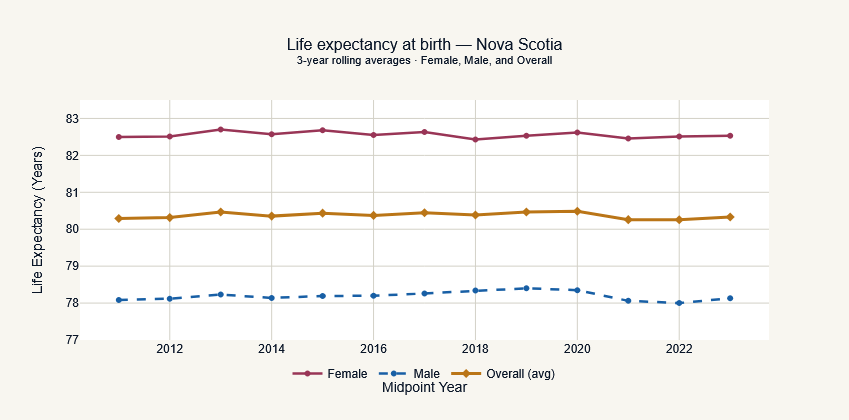

In [5]:
# ============================================================
# 2.2 LIFE EXPECTANCY → Province Level
# ============================================================
life = pd.read_csv('./clean/life_expectancy.csv')
life_birth = life[life['Age group'] == '0 years'].copy()
life_birth['Year'] = life_birth['Year Period'].apply(lambda x: int(x.split(' to ')[0]) + 1)

# Keep gender-level for viz, then average for merge
life_gender = life_birth.groupby(['Year', 'Gender'])['Life Expectancy'].mean().reset_index()
life_yearly = life_birth.groupby('Year')['Life Expectancy'].mean().reset_index()
life_yearly.columns = ['Year', 'Life_Expectancy']

print(f"Life expectancy at birth: {life_yearly['Year'].min()}–{life_yearly['Year'].max()}")
print(f"Range: {life_yearly['Life_Expectancy'].min():.2f} – {life_yearly['Life_Expectancy'].max():.2f} years")
print(f"Total variation over decade: {life_yearly['Life_Expectancy'].max() - life_yearly['Life_Expectancy'].min():.2f} years")

# --- Interactive chart ---
fig = go.Figure()

for gender, color, dash in [('F', NS['pink'], 'solid'), ('M', NS['blue'], 'dash')]:
    gdata = life_gender[life_gender['Gender'] == gender]
    fig.add_trace(go.Scatter(
        x=gdata['Year'], y=gdata['Life Expectancy'],
        name=f"{'Female' if gender == 'F' else 'Male'}",
        mode='lines+markers', line=dict(width=2.5, color=color, dash=dash),
        marker=dict(size=6),
        hovertemplate='<b>%{fullData.name}</b><br>Year: %{x}<br>Life Exp: %{y:.2f} yrs<extra></extra>'
    ))

fig.add_trace(go.Scatter(
    x=life_yearly['Year'], y=life_yearly['Life_Expectancy'],
    name='Overall (avg)', mode='lines+markers',
    line=dict(width=3, color=NS['gold']),
    marker=dict(size=7, symbol='diamond'),
    hovertemplate='<b>Overall</b><br>Year: %{x}<br>Life Exp: %{y:.2f} yrs<extra></extra>'
))

fig.update_layout(
    template=NS_TEMPLATE,
    title='Life expectancy at birth — Nova Scotia<br><sup>3-year rolling averages · Female, Male, and Overall</sup>',
    xaxis_title='Midpoint Year', yaxis_title='Life Expectancy (Years)',
    yaxis=dict(range=[77, 83.5]),
    legend=dict(orientation='h', yanchor='bottom', y=-0.2, xanchor='center', x=0.5),
    height=420, hovermode='x unified'
)
fig.show()


**What we see:** A persistent ~4-year gap between female (82.5) and male (78.1) life expectancy — consistent with national patterns. The overall average barely moves, hovering at 80.3 ± 0.1 years. This **stagnation under universal healthcare** reinforces the premise that health outcomes are shaped by more than just access to doctors.


### 2.3 Income

Income data covers Nova Scotia residents across 6 age brackets and both genders. We extract two complementary metrics:

- **Median income** (excluding zeros): The typical Nova Scotian's earnings — robust to extreme values
- **Average income** (excluding zeros): Pulled upward by high earners, capturing overall economic capacity

Both are averaged across age groups and genders to produce a single province-level number per year. In a universal healthcare context, income matters not for ability to *pay* for care, but for **nutrition, housing, stress, occupational risk, and health literacy** — the upstream determinants.


Income data: 2012–2023


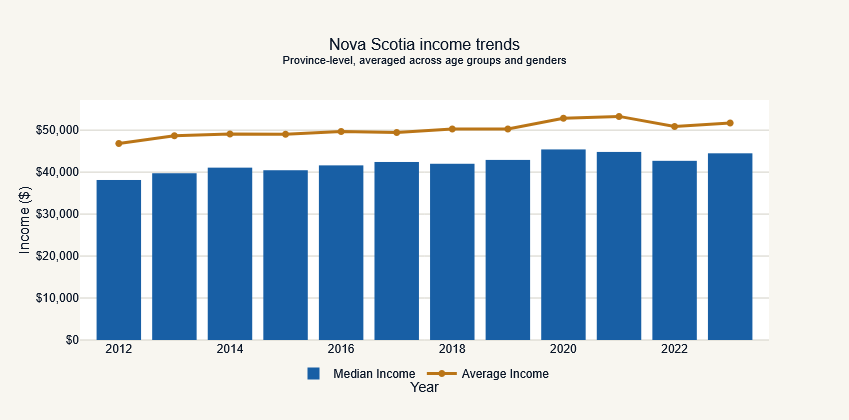

In [6]:
# ============================================================
# 2.3 INCOME → Province Level
# ============================================================
income = pd.read_csv('./clean/income.csv')
income_ns = income[income['Geography'] == 'Nova Scotia'].copy()

income_median = income_ns[income_ns['Statistic'] == 'Median income (excluding zeros)']
income_overall = income_median.groupby('Year')['Value'].mean().reset_index()
income_overall.columns = ['Year', 'Median_Income']

income_avg = income_ns[income_ns['Statistic'] == 'Average income (excluding zeros)']
income_avg_overall = income_avg.groupby('Year')['Value'].mean().reset_index()
income_avg_overall.columns = ['Year', 'Average_Income']

income_combined = income_overall.merge(income_avg_overall, on='Year')

print(f"Income data: {income_combined['Year'].min()}–{income_combined['Year'].max()}")

# --- Interactive chart ---
fig = go.Figure()
fig.add_trace(go.Bar(
    x=income_combined['Year'], y=income_combined['Median_Income'],
    name='Median Income', marker_color=NS['blue'],
    hovertemplate='<b>Median</b><br>%{x}: $%{y:,.0f}<extra></extra>'
))
fig.add_trace(go.Scatter(
    x=income_combined['Year'], y=income_combined['Average_Income'],
    name='Average Income', mode='lines+markers',
    line=dict(width=3, color=NS['gold']), marker=dict(size=7),
    hovertemplate='<b>Average</b><br>%{x}: $%{y:,.0f}<extra></extra>'
))

fig.update_layout(
    template=NS_TEMPLATE,
    title='Nova Scotia income trends<br><sup>Province-level, averaged across age groups and genders</sup>',
    xaxis_title='Year', yaxis_title='Income ($)',
    yaxis=dict(tickformat='$,.0f'),
    legend=dict(orientation='h', yanchor='bottom', y=-0.2, xanchor='center', x=0.5),
    height=420, barmode='group', hovermode='x unified'
)
fig.show()


**What we see:** Median income grew from ~\$38K to ~\$45K (peaking in 2020 during CERB/pandemic transfers) before pulling back. The gap between median and average income widened slightly, suggesting income concentration at the top. The 2020 spike is a real phenomenon — federal pandemic benefits temporarily boosted incomes across the board — and it coincides with a noticeable dip in some chronic disease rates (potentially reduced healthcare utilization during COVID lockdowns, or a genuine income effect).


### 2.4 Education Attainment

Education is measured as the percentage of Nova Scotians in three attainment tiers:

| Level | What it means | Health relevance |
|-------|--------------|-----------------|
| **Tertiary education** | University/college degree | Strongest protective factor — health literacy, occupational safety, informed health decisions |
| **Upper secondary** | High school + some trade/college | Middle ground |
| **Below upper secondary** | Did not complete high school | Vulnerability marker — limited health literacy, higher-risk occupations |

In a universal healthcare system, education's effect operates through **health behaviors** (smoking, diet, exercise), **occupational exposure** (physical labor, shift work), and **health literacy** (understanding symptoms, adhering to treatment, navigating the system). You can have free healthcare and still not know when or how to use it effectively.


Education data: 2012–2025


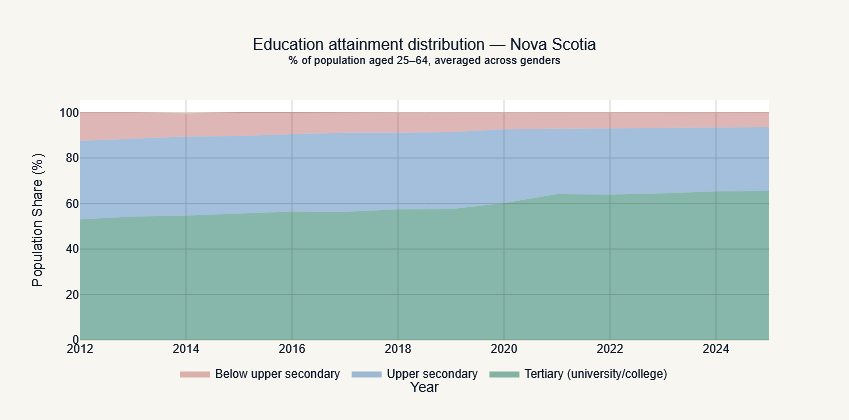

In [8]:
# ============================================================
# 2.4 EDUCATION → Province Level
# ============================================================
edu = pd.read_excel('./clean/Education.xlsx')
edu_ns = edu[edu['Geography'] == 'Nova Scotia'].copy()
edu_ns = edu_ns.dropna(subset=['Education attainment level 10', 'Percent'])
edu_ns['Percent'] = pd.to_numeric(edu_ns['Percent'], errors='coerce')
edu_ns = edu_ns.dropna(subset=['Percent'])

edu_pivot = edu_ns.groupby(['Year', 'Education attainment level 10'])['Percent'].mean().reset_index()
edu_wide = edu_pivot.pivot_table(index='Year', columns='Education attainment level 10', values='Percent').reset_index()
edu_wide.columns.name = None

col_map = {}
for c in edu_wide.columns:
    if 'Tertiary' in str(c):         col_map[c] = 'Tertiary_Edu_Pct'
    elif 'Upper secondary' in str(c): col_map[c] = 'Upper_Secondary_Pct'
    elif 'Below' in str(c):           col_map[c] = 'Below_Upper_Secondary_Pct'
edu_wide.rename(columns=col_map, inplace=True)

print(f"Education data: {edu_wide['Year'].min()}–{edu_wide['Year'].max()}")

# --- Stacked area chart ---
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=edu_wide['Year'], y=edu_wide['Tertiary_Edu_Pct'],
    name='Tertiary (university/college)', mode='lines',
    line=dict(width=0), fill='tozeroy', fillcolor='rgba(15,110,86,0.5)',
    stackgroup='one',
    hovertemplate='Tertiary: %{y:.1f}%<extra></extra>'
))
fig.add_trace(go.Scatter(
    x=edu_wide['Year'], y=edu_wide['Upper_Secondary_Pct'],
    name='Upper secondary', mode='lines',
    line=dict(width=0), fill='tonexty', fillcolor='rgba(24,95,165,0.4)',
    stackgroup='one',
    hovertemplate='Upper secondary: %{y:.1f}%<extra></extra>'
))
fig.add_trace(go.Scatter(
    x=edu_wide['Year'], y=edu_wide['Below_Upper_Secondary_Pct'],
    name='Below upper secondary', mode='lines',
    line=dict(width=0), fill='tonexty', fillcolor='rgba(163,45,45,0.35)',
    stackgroup='one',
    hovertemplate='Below upper secondary: %{y:.1f}%<extra></extra>'
))

fig.update_layout(
    template=NS_TEMPLATE,
    title='Education attainment distribution — Nova Scotia<br><sup>% of population aged 25–64, averaged across genders</sup>',
    xaxis_title='Year', yaxis_title='Population Share (%)',
    legend=dict(orientation='h', yanchor='bottom', y=-0.2, xanchor='center', x=0.5),
    height=420, hovermode='x unified'
)
fig.show()


**What we see:** A dramatic structural shift — tertiary education climbed from 53% to 64% over the decade while the below-upper-secondary population shrank from 12.5% to 7%. Nova Scotia is rapidly becoming a more educated province. The question is: did this education surge coincide with falling chronic disease rates? (Spoiler: it did, powerfully.)


---
## 3. Dataset Merge

All four datasets are merged on `Year` using inner joins. Only years where **every** source has data survive — producing **11 annual observations (2012–2022)**.


In [9]:
# ============================================================
# 3. MERGE ALL DATASETS ON YEAR
# ============================================================
merged = chronic_pivot.merge(life_yearly, on='Year', how='inner')
merged = merged.merge(income_combined, on='Year', how='inner')
merged = merged.merge(edu_wide, on='Year', how='inner')

print(f"✓ Merged dataset: {merged.shape[0]} observations × {merged.shape[1]} variables")
print(f"  Year range: {merged['Year'].min()}–{merged['Year'].max()}")
print(f"  Null values: {merged.isnull().sum().sum()}")

# Define variable groups
socio_vars = ['Median_Income', 'Average_Income', 'Tertiary_Edu_Pct',
              'Upper_Secondary_Pct', 'Below_Upper_Secondary_Pct']

health_vars = ['Life_Expectancy', 'Chronic_Disease_Burden'] + disease_cols

all_vars = socio_vars + health_vars

LABELS = {
    'Median_Income': 'Median Income',
    'Average_Income': 'Average Income',
    'Tertiary_Edu_Pct': 'Tertiary Edu %',
    'Upper_Secondary_Pct': 'Upper Secondary %',
    'Below_Upper_Secondary_Pct': 'Below Upper Sec %',
    'Life_Expectancy': 'Life Expectancy',
    'Chronic_Disease_Burden': 'Disease Burden (Avg)',
    'Acute Myocardial Infarction (AMI)': 'AMI',
    'Asthma': 'Asthma',
    'Diabetes': 'Diabetes',
    'Hypertension': 'Hypertension',
    'Ischemic Heart Disease': 'Ischemic Heart Disease',
}

print(f"\nSocioeconomic variables ({len(socio_vars)}):")
for v in socio_vars: print(f"  • {LABELS[v]}")
print(f"\nHealth outcome variables ({len(health_vars)}):")
for v in health_vars: print(f"  • {LABELS[v]}")


✓ Merged dataset: 11 observations × 13 variables
  Year range: 2012–2022
  Null values: 0

Socioeconomic variables (5):
  • Median Income
  • Average Income
  • Tertiary Edu %
  • Upper Secondary %
  • Below Upper Sec %

Health outcome variables (7):
  • Life Expectancy
  • Disease Burden (Avg)
  • AMI
  • Asthma
  • Diabetes
  • Hypertension
  • Ischemic Heart Disease


---
## 4. Descriptive Statistics

Instead of a static table, let's visualize the **coefficient of variation** (CV%) — how much each variable changed over the decade relative to its mean. High CV = lots of movement; low CV = stagnant. This tells us which variables actually *have* a story to tell.


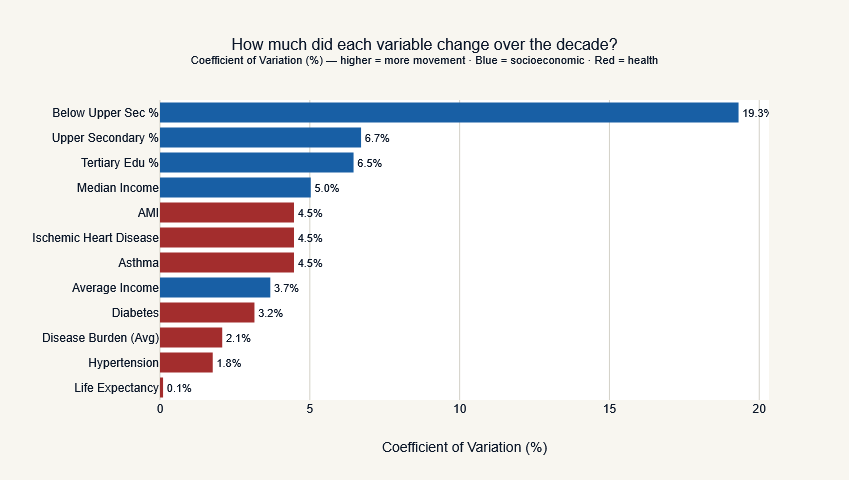

In [10]:
# ============================================================
# 4. DESCRIPTIVE STATS — Coefficient of Variation
# ============================================================
desc = merged[all_vars].describe().T
desc['cv_pct'] = (desc['std'] / desc['mean'].abs()) * 100
desc['label'] = [LABELS.get(v, v) for v in desc.index]
desc['category'] = ['Socioeconomic' if v in socio_vars else 'Health' for v in desc.index]
desc = desc.sort_values('cv_pct', ascending=True)

fig = go.Figure()

colors = [NS['blue'] if cat == 'Socioeconomic' else NS['crimson'] for cat in desc['category']]

fig.add_trace(go.Bar(
    y=desc['label'], x=desc['cv_pct'],
    orientation='h', marker_color=colors,
    text=[f"{v:.1f}%" for v in desc['cv_pct']],
    textposition='outside', textfont=dict(size=11),
    hovertemplate='<b>%{y}</b><br>CV: %{x:.1f}%<br>Mean: %{customdata[0]}<br>Std: %{customdata[1]}<extra></extra>',
    customdata=list(zip(
        [f"{v:,.1f}" for v in desc['mean']],
        [f"{v:,.2f}" for v in desc['std']]
    ))
))

fig.update_layout(
    template=NS_TEMPLATE,
    title='How much did each variable change over the decade?<br><sup>Coefficient of Variation (%) — higher = more movement · Blue = socioeconomic · Red = health</sup>',
    xaxis_title='Coefficient of Variation (%)',
    height=480, margin=dict(l=160),
)
fig.show()


**What we see:** Below-upper-secondary education has the highest variability (it dropped nearly in half), followed by the other education tiers and income. On the health side, AMI/Asthma/IHD show moderate variation while **Life Expectancy is dead last** — barely 0.1% CV, confirming it's essentially flat. This already hints that education will be the strongest correlate: it moved the most on the socioeconomic side, and the diseases that declined the most are on the health side.


---
## 5. Z-Score Standardization

The variables live on wildly different scales:
- Income: ~\$38,000–\$53,000
- Education: ~7%–64%
- Life expectancy: ~80.25–80.49 years (a 0.24-year range!)
- Disease rates: ~78–312 per 1,000

Z-score normalization transforms each to mean=0, standard deviation=1. This is purely for **visual comparison** — the actual correlations are computed on the raw data (Pearson r is scale-invariant).


In [11]:
# ============================================================
# 5. Z-SCORE STANDARDIZATION
# ============================================================
scaler = StandardScaler()
merged_z = pd.DataFrame(
    scaler.fit_transform(merged[all_vars]),
    columns=all_vars, index=merged.index
)
merged_z['Year'] = merged['Year'].values

print("✓ Standardized dataset computed")
print(f"  Column means (should ≈ 0): {merged_z[all_vars].mean().abs().max():.2e}")
print(f"  Column stds  (should ≈ 1): {merged_z[all_vars].std().mean():.4f}")


✓ Standardized dataset computed
  Column means (should ≈ 0): 8.26e-14
  Column stds  (should ≈ 1): 1.0488


---
## 6. Correlation Analysis

### 6.2 Full Correlation Matrix

The complete 12×12 matrix (lower triangle only) reveals the internal structure — including how socioeconomic variables correlate with each other, and how diseases cluster together.


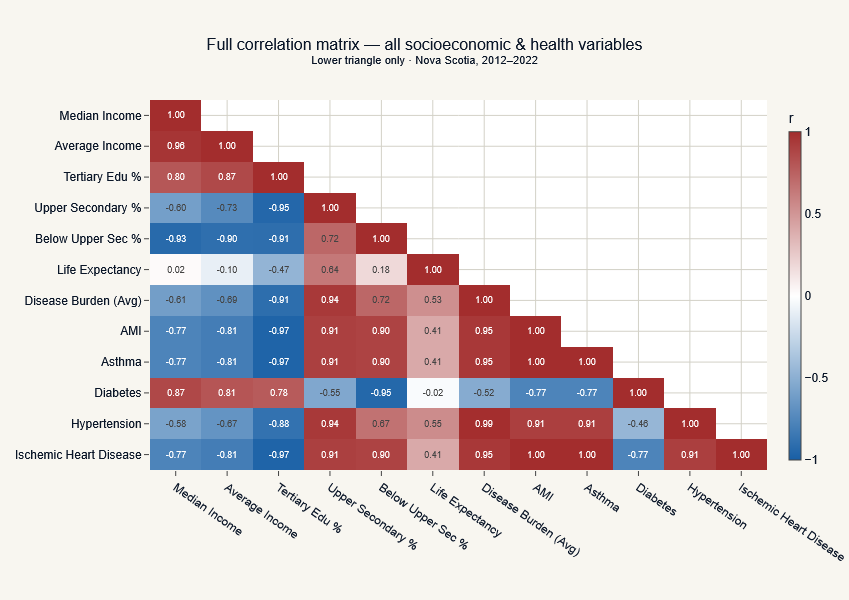

In [13]:
# ============================================================
# 6.2 FULL CORRELATION MATRIX (Lower Triangle)
# ============================================================
labels_all = [LABELS.get(v, v) for v in all_vars]

# Mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
z_masked = corr_matrix.values.copy()
z_masked[mask] = np.nan

# Annotations
annot_full = []
for i in range(len(all_vars)):
    row = []
    for j in range(len(all_vars)):
        if mask[i, j]:
            row.append('')
        else:
            row.append(f"{corr_matrix.iloc[i, j]:.2f}")
    annot_full.append(row)

fig = go.Figure(data=go.Heatmap(
    z=z_masked,
    x=labels_all, y=labels_all,
    text=annot_full, texttemplate='%{text}', textfont=dict(size=9),
    colorscale=[[0, NS['blue']], [0.5, NS['white']], [1, NS['crimson']]],
    zmin=-1, zmax=1,
    colorbar=dict(title='r', thickness=12),
    hovertemplate='<b>%{y} × %{x}</b><br>r = %{z:.3f}<extra></extra>'
))

fig.update_layout(
    template=NS_TEMPLATE,
    title='Full correlation matrix — all socioeconomic & health variables<br><sup>Lower triangle only · Nova Scotia, 2012–2022</sup>',
    height=600, width=700, margin=dict(l=150, b=130),
    xaxis=dict(tickangle=35), yaxis=dict(autorange='reversed'),
)
fig.show()


**Structural insights from the full matrix:**

- **Socioeconomic variables are highly intercorrelated** — Median and Average Income at r = 0.96, Tertiary Edu and Below-Upper-Secondary at r = −0.91. This multicollinearity means we shouldn't run multiple regression with all five as independent variables (they'd step on each other). The correlation analysis is the right tool here.

- **The disease cluster:** AMI, Asthma, and Ischemic Heart Disease are nearly perfectly correlated (r ≈ 1.00) — they move together in lockstep. Hypertension follows closely (r ≈ 0.91). This disease bloc represents the **cardiovascular-respiratory cluster** driven by shared risk factors.

- **Diabetes stands alone** — negatively correlated with the other diseases (r ≈ −0.77) despite being the same kind of chronic condition. This confirms it's behaving differently for structural reasons (detection), not random noise.


---
## 7. Key Scatter Plots

Four relationships selected for their analytical importance — the strongest protective correlation, the strongest risk marker, the diabetes paradox, and the income–disease link.


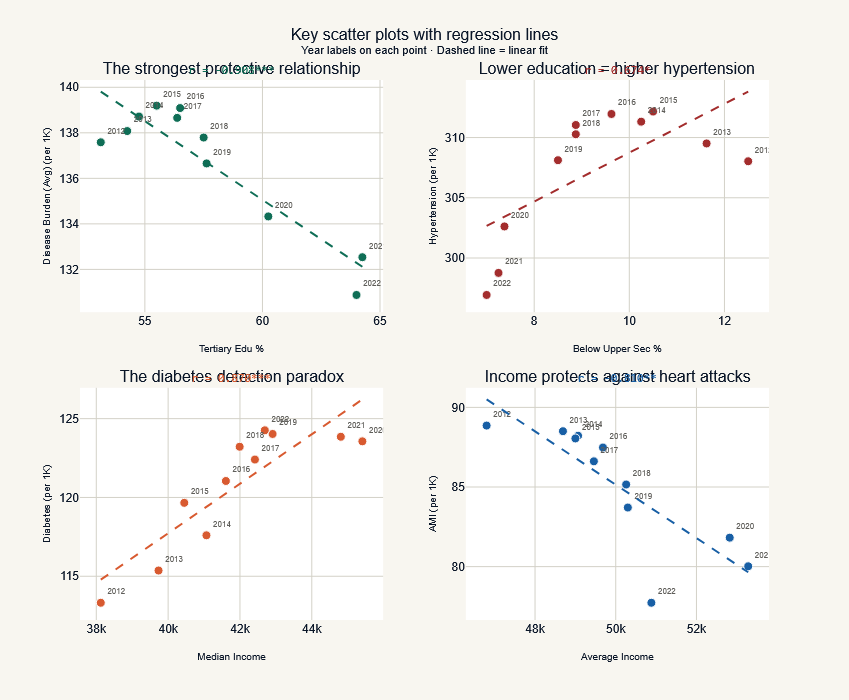

In [14]:
# ============================================================
# 7. SCATTER PLOTS — Interactive with Regression Lines
# ============================================================
scatter_config = [
    ('Tertiary_Edu_Pct', 'Chronic_Disease_Burden', NS['teal'], 'The strongest protective relationship'),
    ('Below_Upper_Secondary_Pct', 'Hypertension', NS['crimson'], 'Lower education = higher hypertension'),
    ('Median_Income', 'Diabetes', NS['coral'], 'The diabetes detection paradox'),
    ('Average_Income', 'Acute Myocardial Infarction (AMI)', NS['blue'], 'Income protects against heart attacks'),
]

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[c[3] for c in scatter_config],
    horizontal_spacing=0.12, vertical_spacing=0.14,
)

for idx, (sv, hv, color, title) in enumerate(scatter_config):
    row, col = idx // 2 + 1, idx % 2 + 1
    x, y = merged[sv], merged[hv]
    slope, intercept, r, p, se = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 50)
    y_line = slope * x_line + intercept

    stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))

    fig.add_trace(go.Scatter(
        x=x, y=y, mode='markers+text',
        text=merged['Year'].astype(str), textposition='top right', textfont=dict(size=8, color=NS['slate']),
        marker=dict(size=9, color=color, line=dict(width=1, color='white')),
        name=f"{LABELS[sv]} × {LABELS[hv]}",
        hovertemplate=f'<b>%{{text}}</b><br>{LABELS[sv]}: %{{x:,.1f}}<br>{LABELS[hv]}: %{{y:.1f}}<extra></extra>',
        showlegend=False
    ), row=row, col=col)

    fig.add_trace(go.Scatter(
        x=x_line, y=y_line, mode='lines',
        line=dict(dash='dash', width=2, color=color),
        name=f'r={r:.2f}{stars}', showlegend=False,
        hoverinfo='skip'
    ), row=row, col=col)

    ax_suffix = '' if idx == 0 else str(idx + 1)
    fig.add_annotation(
        x=0.5, y=1.0, xref=f'x{ax_suffix} domain', yref=f'y{ax_suffix} domain',
        text=f'r = {r:.3f}{stars}', showarrow=False,
        font=dict(size=12, color=color, family='monospace'),
        xanchor='center', yanchor='bottom'
    )

    fig.update_xaxes(title_text=LABELS[sv], row=row, col=col, title_font=dict(size=10))
    fig.update_yaxes(title_text=LABELS[hv] + ' (per 1K)', row=row, col=col, title_font=dict(size=10))

fig.update_layout(
    template=NS_TEMPLATE,
    title='Key scatter plots with regression lines<br><sup>Year labels on each point · Dashed line = linear fit</sup>',
    height=700, showlegend=False, margin=dict(t=80)
)
fig.show()


**Reading the scatter plots:**

**Top-left (Tertiary Education × Disease Burden, r = −0.91):** The tightest cluster — as tertiary education rose from 53% to 64%, composite disease burden dropped from 138 to 131. The 2021–2022 points pull sharply down-left, suggesting the education surge of recent years coincided with accelerated health improvement.

**Top-right (Below Upper Secondary × Hypertension, r = +0.67):** Less educated population segments associate with higher hypertension rates. The causal chain runs through diet, smoking, occupational stress, and health literacy — all factors that free healthcare cannot fix.

**Bottom-left (Median Income × Diabetes, r = +0.87):** The paradox in visual form — income goes *up*, diabetes goes *up*. This isn't because wealth causes diabetes; it's because wealthier populations have better screening access and diagnostic rates. The disease isn't increasing — our *measurement* of it is improving.

**Bottom-right (Average Income × AMI, r = −0.81):** The expected protective pattern — higher incomes associate with fewer heart attacks. Note 2020's jump to the far right (pandemic income transfers) coinciding with the lowest AMI rate.


---
## 9. Significant Findings

Rather than a table, let's visualize all 29 significant correlation pairs (|r| ≥ 0.6, p < 0.05) as a **lollipop chart** sorted by absolute correlation strength. This immediately shows which relationships dominate.


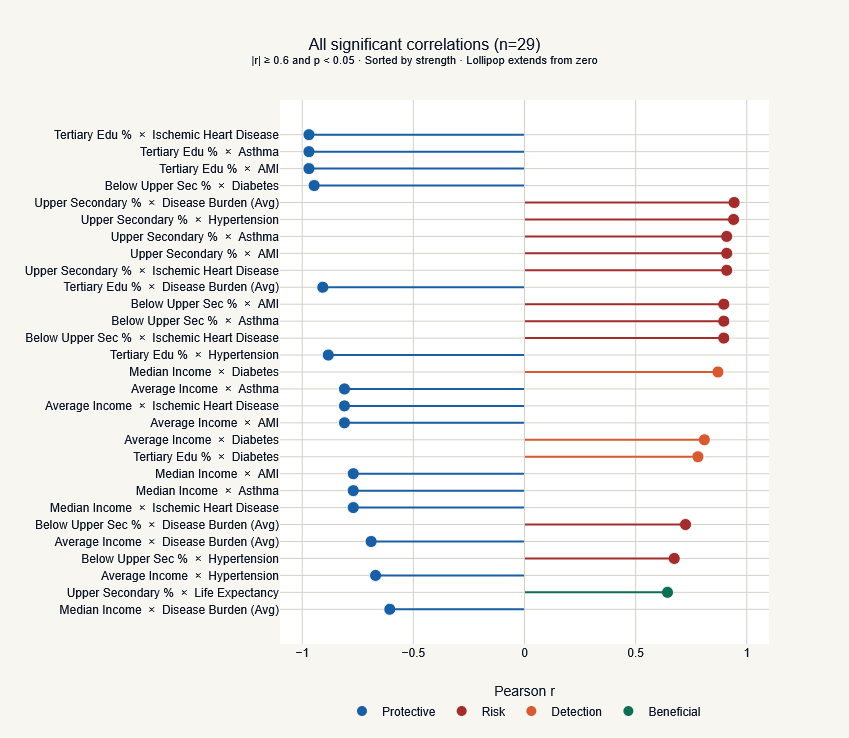

In [16]:
# ============================================================
# 9. SIGNIFICANT FINDINGS — Lollipop Chart
# ============================================================
findings = []
for sv in socio_vars:
    for hv in health_vars:
        r = cross_corr.loc[sv, hv]
        p = cross_pval.loc[sv, hv]
        if abs(r) >= 0.6 and p < 0.05:
            if hv == 'Life_Expectancy':
                interp = 'Beneficial' if r > 0 else 'Harmful'
            elif hv == 'Diabetes' and r > 0:
                interp = 'Detection'
            else:
                interp = 'Protective' if r < 0 else 'Risk'
            findings.append({
                'pair': f"{LABELS[sv]}  ×  {LABELS[hv]}",
                'r': r, 'abs_r': abs(r), 'p': p,
                'interp': interp, 'socio': sv, 'health': hv,
                'strength': 'Very Strong' if abs(r) >= 0.9 else ('Strong' if abs(r) >= 0.7 else 'Moderate')
            })

findings_df = pd.DataFrame(findings).sort_values('abs_r', ascending=True)

color_map = {'Protective': NS['blue'], 'Risk': NS['crimson'], 'Detection': NS['coral'], 'Beneficial': NS['teal']}

fig = go.Figure()

for _, row in findings_df.iterrows():
    c = color_map[row['interp']]
    fig.add_trace(go.Scatter(
        x=[row['r']], y=[row['pair']], mode='markers',
        marker=dict(size=12, color=c, line=dict(width=1, color='white')),
        showlegend=False,
        hovertemplate=f"<b>{row['pair']}</b><br>r = {row['r']:.3f}<br>p = {row['p']:.4f}<br>{row['interp']} ({row['strength']})<extra></extra>"
    ))
    fig.add_shape(
        type='line', x0=0, x1=row['r'],
        y0=row['pair'], y1=row['pair'],
        line=dict(color=c, width=2)
    )

fig.add_vline(x=0, line_color=NS['warm_gray'], line_width=1)

# Legend entries
for interp, c in color_map.items():
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(size=10, color=c), name=interp
    ))

fig.update_layout(
    template=NS_TEMPLATE,
    title=f'All significant correlations (n={len(findings_df)})<br><sup>|r| ≥ 0.6 and p < 0.05 · Sorted by strength · Lollipop extends from zero</sup>',
    xaxis=dict(title='Pearson r', range=[-1.1, 1.1], zeroline=True),
    yaxis=dict(title=''),
    height=max(500, len(findings_df) * 22 + 100),
    margin=dict(l=280),
    legend=dict(orientation='h', yanchor='bottom', y=-0.15, xanchor='center', x=0.5),
    showlegend=True,
)
fig.show()


**Reading the lollipop chart:**

The **blue protective cluster** dominates the left side — higher education and income consistently associate with lower disease rates. The top 3 correlations are all Tertiary Education against cardiovascular/respiratory diseases (r = −0.97).

The **red risk lines** on the right show the reverse — populations with only upper-secondary or below-upper-secondary education associate with *higher* disease burden.

The **orange detection lines** are the Diabetes paradox — the only disease moving right (positive) with income and education, because of improved screening rather than worsening health.

The single **teal beneficial line** is Upper Secondary % × Life Expectancy (r = +0.64) — the only significant life expectancy correlation, and the weakest in the entire chart.


---
## 10. The Diabetes Paradox: When "More Cases" Means Better Healthcare

Diabetes is the **only** chronic disease that correlates *positively* with income and education — the exact opposite of what we'd expect. In a province where healthcare is free, why would wealthier, better-educated communities have *more* diagnosed diabetes?

**The answer: diagnostic ascertainment bias.**

As socioeconomic status rises, people are more likely to:
1. **Have a regular family doctor** — NS has an ongoing primary care attachment crisis (~100K+ residents without a GP). Higher-income communities tend to have better attachment rates.
2. **Get screened proactively** — diabetes is often asymptomatic for years. It's caught through blood work at routine checkups, not emergency visits.
3. **Receive a formal diagnosis and enter CCDSS tracking** — the surveillance system captures diagnosed cases, not actual prevalence.

So the diabetes rate isn't *increasing* because people are sicker — it's increasing because more cases are being **found and recorded**. The healthcare system is free, but *using* it proactively requires access to a GP, health literacy, and the time/ability to attend appointments — all socioeconomically mediated.

The other diseases (AMI, Hypertension, Asthma, IHD) don't show this pattern because their symptoms are more **acute** and less dependent on elective screening — you go to the ER when you have a heart attack or an asthma crisis regardless of education level.


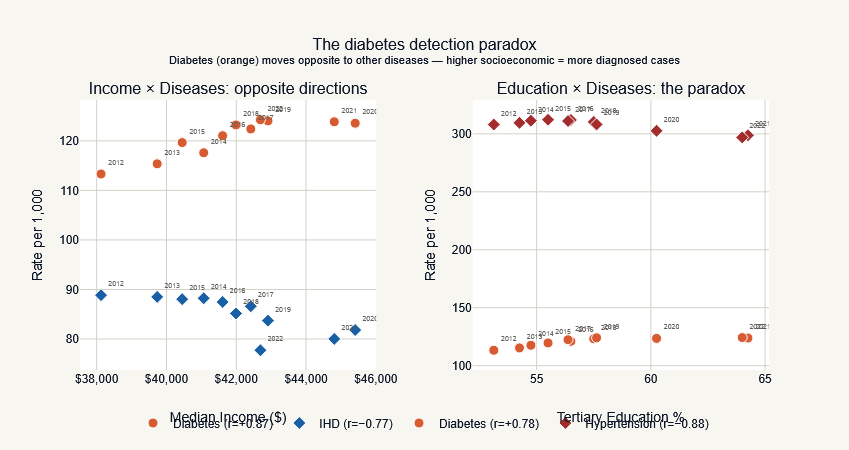

In [17]:
# ============================================================
# 10. DIABETES PARADOX VISUALIZATION
# ============================================================
fig = make_subplots(
    rows=1, cols=2, subplot_titles=[
        'Income × Diseases: opposite directions',
        'Education × Diseases: the paradox'
    ], horizontal_spacing=0.14
)

# Panel A: Income vs Diabetes (positive) & IHD (negative)
for hv, color, name, symbol in [
    ('Diabetes', NS['coral'], 'Diabetes (r=+0.87)', 'circle'),
    ('Ischemic Heart Disease', NS['blue'], 'IHD (r=−0.77)', 'diamond'),
]:
    fig.add_trace(go.Scatter(
        x=merged['Median_Income'], y=merged[hv],
        name=name, mode='markers+text',
        text=merged['Year'].astype(str), textposition='top right', textfont=dict(size=7, color=NS['slate']),
        marker=dict(size=10, color=color, symbol=symbol, line=dict(width=1, color='white')),
        hovertemplate=f'<b>{name}</b><br>Income: $%{{x:,.0f}}<br>Rate: %{{y:.1f}}<extra></extra>',
    ), row=1, col=1)

# Panel B: Education vs Diabetes (positive) & Hypertension (negative)
for hv, color, name, symbol in [
    ('Diabetes', NS['coral'], 'Diabetes (r=+0.78)', 'circle'),
    ('Hypertension', NS['crimson'], 'Hypertension (r=−0.88)', 'diamond'),
]:
    fig.add_trace(go.Scatter(
        x=merged['Tertiary_Edu_Pct'], y=merged[hv],
        name=name, mode='markers+text',
        text=merged['Year'].astype(str), textposition='top right', textfont=dict(size=7, color=NS['slate']),
        marker=dict(size=10, color=color, symbol=symbol, line=dict(width=1, color='white')),
        hovertemplate=f'<b>{name}</b><br>Tertiary Edu: %{{x:.1f}}%<br>Rate: %{{y:.1f}}<extra></extra>',
    ), row=1, col=2)

fig.update_xaxes(title_text='Median Income ($)', tickformat='$,.0f', row=1, col=1)
fig.update_xaxes(title_text='Tertiary Education %', row=1, col=2)
fig.update_yaxes(title_text='Rate per 1,000', row=1, col=1)
fig.update_yaxes(title_text='Rate per 1,000', row=1, col=2)

fig.update_layout(
    template=NS_TEMPLATE,
    title='The diabetes detection paradox<br><sup>Diabetes (orange) moves opposite to other diseases — higher socioeconomic = more diagnosed cases</sup>',
    height=450, legend=dict(orientation='h', yanchor='bottom', y=-0.25, xanchor='center', x=0.5),
)
fig.show()


---
## 11. CSV Exports for Power BI

Three files structured for a Power BI star schema:

| File | Rows × Cols | Power BI Role | Description |
|------|-------------|--------------|-------------|
| `fact_socio_health.csv` | 11 × 13 | Fact table | Raw merged values by year |
| `fact_socio_health_standardized.csv` | 11 × 13 | Fact table (alt) | Z-score version for dual-axis visuals |
| `dim_correlation_matrix.csv` | 35 × 11 | Dimension | Cross-correlation pairs with r, p, significance, strength, and interpretation labels |

The `dim_correlation_matrix.csv` is especially useful in Power BI — load it as a table visual with conditional formatting on `Pearson_r` (blue-white-red diverging), filter by `Significant = TRUE`, and sort by `Abs_r` descending.


In [ ]:
# ============================================================
# 11. CSV EXPORTS FOR POWER BI
# ============================================================

# --- Fact Table: Raw ---
fact_raw = merged.copy()
fact_raw.to_csv('fact_socio_health.csv', index=False)
print(f"✓ fact_socio_health.csv — {fact_raw.shape[0]} × {fact_raw.shape[1]}")

# --- Fact Table: Standardized ---
fact_z = merged_z.copy()
fact_z.to_csv('fact_socio_health_standardized.csv', index=False)
print(f"✓ fact_socio_health_standardized.csv — {fact_z.shape[0]} × {fact_z.shape[1]}")

# --- Dimension: Correlation Matrix ---
corr_records = []
for sv in socio_vars:
    for hv in health_vars:
        r_val = cross_corr.loc[sv, hv]
        p_val = cross_pval.loc[sv, hv]
        if hv == 'Life_Expectancy':
            direction = 'Beneficial' if r_val > 0 else 'Harmful'
        elif hv == 'Diabetes' and r_val > 0:
            direction = 'Detection Effect'
        else:
            direction = 'Protective' if r_val < 0 else 'Risk'

        corr_records.append({
            'Socioeconomic_Variable': sv,
            'Socioeconomic_Label': LABELS.get(sv, sv),
            'Health_Variable': hv,
            'Health_Label': LABELS.get(hv, hv),
            'Pearson_r': round(r_val, 4),
            'Abs_r': round(abs(r_val), 4),
            'P_Value': round(p_val, 6),
            'Significant': p_val < 0.05,
            'Strength': 'Very Strong' if abs(r_val) >= 0.9 else ('Strong' if abs(r_val) >= 0.7 else ('Moderate' if abs(r_val) >= 0.5 else 'Weak')),
            'Direction': direction,
        })

dim_corr = pd.DataFrame(corr_records)
dim_corr.to_csv('dim_correlation_matrix.csv', index=False)
print(f"✓ dim_correlation_matrix.csv — {dim_corr.shape[0]} × {dim_corr.shape[1]}")
print(f"\n✓ All exports complete — ready for Power BI import")


---
## 12. Conclusions: What This Means for Nova Scotia

### The Core Finding

**In a province with universal, publicly funded healthcare, socioeconomic conditions remain the strongest predictor of chronic disease burden.** Education alone explains 94% of the variance in the cardiovascular-respiratory disease cluster (r² = 0.94 for Tertiary Edu × AMI/IHD/Asthma).

### What "Free Healthcare" Does and Doesn't Fix

| What universal coverage DOES | What it DOESN'T |
|------------------------------|-----------------|
| Removes financial barriers to treatment | Fix upstream determinants (poverty, diet, housing) |
| Ensures emergency care is equal-access | Guarantee equal primary care attachment (GP shortage) |
| Provides hospital services at no cost | Address health literacy gaps |
| Covers prescription drugs (partially, via Pharmacare) | Change occupational risk exposure |
| | Eliminate diagnostic detection bias (diabetes paradox) |

### Policy Implications

1. **Invest in education** — it's the most powerful health intervention that isn't a health intervention. Every percentage point of tertiary education gained associates with measurable disease reduction.

2. **Address the GP attachment crisis** — the diabetes paradox reveals that even "free" healthcare has an access layer. If you can't get a family doctor, you can't get screened.

3. **Target upstream determinants** — income support, nutritional programs, housing quality, and workplace safety may yield greater health dividends per dollar than additional clinical capacity.

4. **Don't confuse equal access with equal outcomes** — the correlation data shows that even under identical healthcare policy, health outcomes track socioeconomic status almost perfectly.

### Connection to NS Healthcare Access Project

This analysis adds a **socioeconomic dimension** to the healthcare access mismatch work. Communities with lower education attainment and income are not only underserved (as the access analysis showed via primary care attachment rates and deprivation scores) — they also carry disproportionate chronic disease burden. The policy recommendation is clear: **healthcare resource allocation should weight both access gaps and socioeconomic vulnerability.**

### Limitations

- **n = 11** annual observations — correlations are strong but confidence intervals are wide. We cannot reliably run multivariate regression with this sample size.
- **Ecological fallacy** — province-level correlations may not hold at the individual or community level. If health-zone-level income and education data becomes available, the analysis should be repeated at that granularity.
- **Temporal confounding** — both socioeconomic indicators and disease rates trend over time, which can inflate correlations. A time-lagged analysis (does education in year *t* predict disease in year *t+3*?) would strengthen causal inference but requires a longer overlap window.
- **No causation** — correlation ≠ causation. Unmeasured confounders (population aging, immigration patterns, healthcare policy changes, COVID disruptions) likely contribute. This analysis identifies **associations worth investigating**, not proven causal pathways.

---

*This notebook extends the Nova Scotia Healthcare Access project. For the mismatch analysis cross-referencing primary care attachment, chronic disease burden, and deprivation scores by health zone, see the companion analysis.*
